In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/Autism Image Dataset"
train_path = base_path + "/train"
valid_path = base_path + "/valid"

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

valid_gen = val_datagen.flow_from_directory(
    valid_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 0 images belonging to 0 classes.
Found 100 images belonging to 2 classes.


In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class MetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, valid_gen, interval=5):
        super().__init__()
        self.valid_gen = valid_gen
        self.interval = interval
        self.history = {'epoch': [], 'f1': [], 'precision': [], 'recall': []}

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.interval == 0:
            y_true = self.valid_gen.classes
            y_pred = self.model.predict(self.valid_gen)
            y_pred = (y_pred > 0.5).astype(int).flatten()

            f1 = f1_score(y_true, y_pred)
            precision = precision_score(y_true, y_pred)
            recall = recall_score(y_true, y_pred)

            print(f"\n📊 Epoch {epoch+1} Evaluation:")
            print(f"F1-score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

            self.history['epoch'].append(epoch+1)
            self.history['f1'].append(f1)
            self.history['precision'].append(precision)
            self.history['recall'].append(recall)

metrics_callback = MetricsCallback(valid_gen, interval=5)


In [ ]:
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths
base_path = "/content/drive/MyDrive/Autism Image Dataset"
train_path = os.path.join(base_path, "train")
valid_path = os.path.join(base_path, "valid")

# --- Create dataframe for train ---
train_files = os.listdir(train_path)
train_df = pd.DataFrame({
    'filename': [os.path.join(train_path, f) for f in train_files],
    'label': ['Autistic' if f.startswith('Autistic') else 'Non_Autistic' for f in train_files]
})

print("Train samples:", len(train_df))
print(train_df.head())

# --- Validation loader (still has subfolders, so keep flow_from_directory) ---
val_datagen = ImageDataGenerator(rescale=1./255)
valid_gen = val_datagen.flow_from_directory(
    valid_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# --- Train loader using flow_from_dataframe ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='label',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)


Train samples: 2540
                                            filename         label
0  /content/drive/MyDrive/Autism Image Dataset/tr...  Non_Autistic
1  /content/drive/MyDrive/Autism Image Dataset/tr...  Non_Autistic
2  /content/drive/MyDrive/Autism Image Dataset/tr...  Non_Autistic
3  /content/drive/MyDrive/Autism Image Dataset/tr...  Non_Autistic
4  /content/drive/MyDrive/Autism Image Dataset/tr...  Non_Autistic
Found 100 images belonging to 2 classes.
Found 2540 validated image filenames belonging to 2 classes.


In [ ]:
history = model.fit(
    train_gen,
    epochs=20,
    validation_data=valid_gen,
    callbacks=[metrics_callback]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.5680 - loss: 0.7852 - val_accuracy: 0.6300 - val_loss: 0.6084
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 297ms/step - accuracy: 0.7022 - loss: 0.5911 - val_accuracy: 0.6900 - val_loss: 0.6071
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 296ms/step - accuracy: 0.7096 - loss: 0.5849 - val_accuracy: 0.7100 - val_loss: 0.5834
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 290ms/step - accuracy: 0.7337 - loss: 0.5468 - val_accuracy: 0.7800 - val_loss: 0.5179
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step

📊 Epoch 5 Evaluation:
F1-score: 0.8247, Precision: 0.8511, Recall: 0.8000
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 310ms/step - accuracy: 0.7480 - loss: 0.5064 - val_accuracy: 0.8300 - val_loss: 0.5018
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 297ms/step - accuracy: 0.7617 - loss: 0.5045 - val_accuracy: 0.7400 - val_loss: 0.5065
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 300ms/step - accuracy: 0.7636 - loss: 0.4994 - val_accuracy: 0.7400 - val

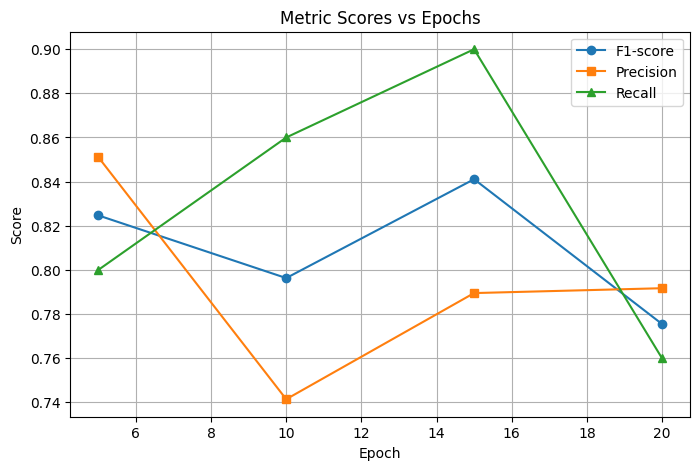

In [ ]:
import matplotlib.pyplot as plt

# Metric values from your logs
epochs = [5, 10, 15, 20]
f1_scores = [0.8247, 0.7963, 0.8411, 0.7755]
precision_scores = [0.8511, 0.7414, 0.7895, 0.7917]
recall_scores = [0.8000, 0.8600, 0.9000, 0.7600]

# Plot
plt.figure(figsize=(8,5))
plt.plot(epochs, f1_scores, marker='o', label='F1-score')
plt.plot(epochs, precision_scores, marker='s', label='Precision')
plt.plot(epochs, recall_scores, marker='^', label='Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Metric Scores vs Epochs')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
model.save("/content/drive/MyDrive/autism_detector_model_final.h5")


In [ ]:
import os

path = "/content/drive/MyDrive/autism_detector_model_final.h5"
print("✅ File found!" if os.path.exists(path) else "❌ File not found.")

✅ File found!
